In [82]:
import uproot
import numpy as np

# Open both files
f_old = uproot.open("PixelSim_ePix/outputs/sparse_sim_run_1.root")
f_new = uproot.open("PixelSim_ePix_Data_Gen/outputs/sparse_sim_run_1.root")

# Compare EdepMap (H2 ID 0)
edep_old = f_old["EdepMap"].to_numpy()  # returns (values, xedges, yedges)
edep_new = f_new["EdepMap"].to_numpy()

# Check bin contents are identical
assert np.allclose(edep_old[0], edep_new[0], rtol=1e-10), "EdepMap differs!"
print("EdepMap: PASS - histograms are identical")

# Compare EntryMap (H2 ID 1)
entry_old = f_old["EntryMap"].to_numpy()
entry_new = f_new["EntryMap"].to_numpy()

assert np.allclose(entry_old[0], entry_new[0], rtol=1e-10), "EntryMap differs!"
print("EntryMap: PASS - histograms are identical")

# Compare H1 histograms
total_old = f_old["TotalEdep"].to_numpy()
total_new = f_new["TotalEdep"].to_numpy()
assert np.allclose(total_old[0], total_new[0], rtol=1e-10), "TotalEdep differs!"
print("TotalEdep: PASS")

primary_old = f_old["PrimaryEdep"].to_numpy()
primary_new = f_new["PrimaryEdep"].to_numpy()
assert np.allclose(primary_old[0], primary_new[0], rtol=1e-10), "PrimaryEdep differs!"
print("PrimaryEdep: PASS")

print("\nAll histograms match — simulation physics is identical.")

AssertionError: EdepMap differs!

In [83]:
f_old.keys()

['Hits;1',
 'Tracks;1',
 'Events;1',
 'Pixels;1',
 'TotalEdep;1',
 'PrimaryEdep;1',
 'EdepMap;1',
 'EntryMap;1']

In [87]:
f_new.keys()

['TotalEdep;1', 'PrimaryEdep;1', 'EdepMap;1', 'EntryMap;1']

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [84]:
edep_old = f_old["EdepMap"].to_numpy()
edep_new = f_new["EdepMap"].to_numpy()

In [85]:
edep_old[0].flatten()

array([ 0.       ,  0.       , 16.0050119, ...,  0.       ,  0.       ,
        0.       ])

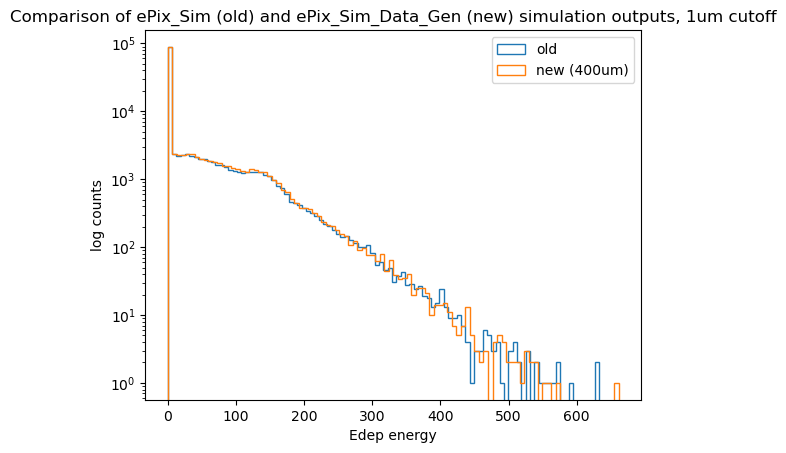

In [88]:
plt.hist(edep_old[0].flatten(),histtype='step',bins=100, label='old')
plt.hist(edep_new[0].flatten(),histtype='step',bins=100, label='new (400um)');
plt.yscale('log')
plt.legend()
plt.ylabel("log counts")
plt.xlabel("Edep energy")
plt.title("Comparison of ePix_Sim (old) and ePix_Sim_Data_Gen (new) simulation outputs, 1um cutoff");

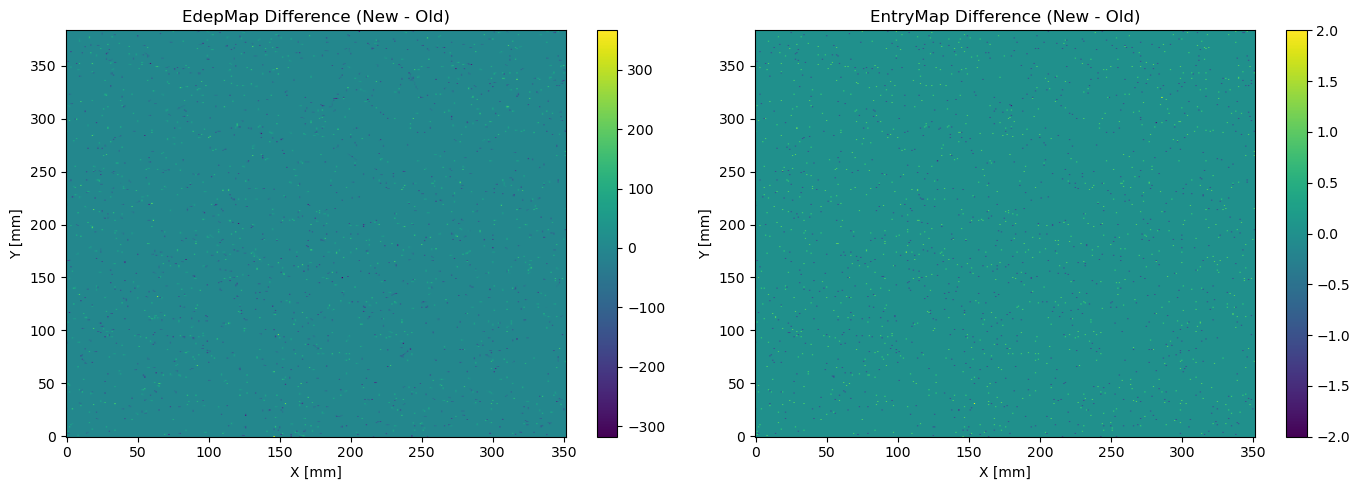

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EdepMap difference
diff = edep_new[0] - edep_old[0]
im = axes[0].imshow(diff.T, origin='lower', aspect='auto',cmap='viridis')
axes[0].set_title("EdepMap Difference (New - Old)")
axes[0].set_xlabel("X [mm]")
axes[0].set_ylabel("Y [mm]")
plt.colorbar(im, ax=axes[0])

# EntryMap difference
diff2 = entry_new[0] - entry_old[0]
im2 = axes[1].imshow(diff2.T, origin='lower', aspect='auto',cmap='viridis')
axes[1].set_title("EntryMap Difference (New - Old)")
axes[1].set_xlabel("X [mm]")
axes[1].set_ylabel("Y [mm]")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

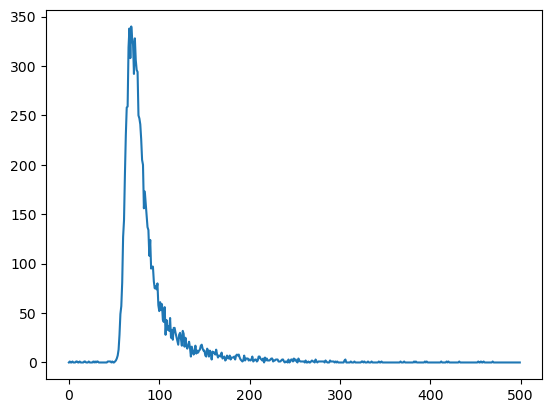

In [33]:
plt.plot(f_old['TotalEdep'].to_numpy()[0])

In [14]:
import uproot
import numpy as np
from scipy import stats

f_old = uproot.open("PixelSim_ePix/outputs/sparse_sim_run_1.root")
f_new = uproot.open("PixelSim_ePix_Data_Gen/outputs/sparse_sim_run_1.root")

# --- Test 1: Total energy in EdepMap should match ---
edep_old, _, _ = f_old["EdepMap"].to_numpy()
edep_new, _, _ = f_new["EdepMap"].to_numpy()

total_old = edep_old.sum()
total_new = edep_new.sum()
# For 100k events, expect ~same total within statistical fluctuation
# Relative difference should be < 1/sqrt(N) ~ 0.3%
rel_diff = abs(total_old - total_new) / (0.5 * (total_old + total_new))
print(f"Total Edep relative difference: {rel_diff:.4%}")
assert rel_diff < 0.01, "Total energy deposited differs by >1%!"

# --- Test 2: Compare 1D Edep spectra (Kolmogorov-Smirnov test) ---
h1_old, edges_old = f_old["TotalEdep"].to_numpy()
h1_new, edges_new = f_new["TotalEdep"].to_numpy()

# Convert histogram to samples for KS test (approximate)
centers = 0.5 * (edges_old[:-1] + edges_old[1:])
samples_old = np.repeat(centers, h1_old.astype(int))
samples_new = np.repeat(centers, h1_new.astype(int))

ks_stat, ks_pvalue = stats.ks_2samp(samples_old, samples_new)
print(f"KS test: statistic={ks_stat:.4f}, p-value={ks_pvalue:.4f}")
assert ks_pvalue > 0.01, "Distributions are statistically different!"
print("PASS: Distributions are statistically consistent")

# --- Test 3: Check Landau MPV is consistent ---
# Find the mode (most probable value) of the primary edep distribution
h1_primary_old, edges_p = f_old["PrimaryEdep"].to_numpy()
h1_primary_new, _       = f_new["PrimaryEdep"].to_numpy()

mpv_old = centers[np.argmax(h1_primary_old)]
mpv_new = centers[np.argmax(h1_primary_new)]
print(f"Landau MPV - Old: {mpv_old:.4f} MeV, New: {mpv_new:.4f} MeV")
# Should be within one bin width
bin_width = edges_p[1] - edges_p[0]
assert abs(mpv_old - mpv_new) <= bin_width, "MPV shifted by more than one bin!"
print("PASS: Landau MPV consistent")

# --- Test 4: Spatial uniformity check ---
# Project EdepMap onto X and Y axes, compare shapes
proj_x_old = edep_old.sum(axis=1)  # sum over Y
proj_x_new = edep_new.sum(axis=1)

proj_y_old = edep_old.sum(axis=0)  # sum over X
proj_y_new = edep_new.sum(axis=0)

# Normalize and compare
proj_x_old_norm = proj_x_old / proj_x_old.sum()
proj_x_new_norm = proj_x_new / proj_x_new.sum()

max_proj_diff = np.max(np.abs(proj_x_old_norm - proj_x_new_norm))
print(f"Max X-projection shape difference: {max_proj_diff:.2e}")
assert max_proj_diff < 0.01, "Spatial distribution shape differs!"
print("PASS: Spatial distributions consistent")

Total Edep relative difference: 22.8269%


AssertionError: Total energy deposited differs by >1%!